In [1]:
import numpy as np
import torch, torch.nn as nn
import gymnasium as gym

In [2]:
import sys
sys.path.insert(0, '..')
gym.register(id='Dragonsweeper-v0', entry_point="Environment:DragonSweeperEnv")
device = torch.device("cpu")

In [3]:
env = gym.make("Dragonsweeper-v0", render_mode=None)

In [4]:
def flat_obs(obs, device=device):
    board = torch.tensor(obs['board'], dtype=torch.float32, device=device).flatten()
    player = torch.tensor(obs['player'], dtype=torch.float32, device=device).flatten()
    return torch.cat((board, player), dim=0)

In [5]:
obs_size = len(flat_obs(env.reset()[0])) # TODO: Remove this before end, yucky pointless reset
channel_size = 512
num_actions = env.action_space.n

In [97]:
embedding_size = 512 # 10 * 13 * 4 rounded down to nearest power of 2, approximately 4 dimensions to embed each cell into

In [105]:
policy_net = torch.nn.Sequential(
    nn.Linear(obs_size, embedding_size), # Embedding
    nn.LayerNorm(embedding_size),
    nn.ReLU(),
    nn.Linear(embedding_size, channel_size),
    nn.LayerNorm(channel_size),
    nn.ReLU(),
    nn.Linear(channel_size, channel_size),
    nn.LayerNorm(channel_size),
    nn.ReLU(),
    nn.Linear(channel_size, channel_size),
    nn.LayerNorm(channel_size),
    nn.ReLU(),
    nn.Linear(channel_size, num_actions)
)
        
value_net = torch.nn.Sequential(
    nn.Linear(obs_size, embedding_size), # Embedding
    nn.LayerNorm(embedding_size),
    nn.ReLU(),
    nn.Linear(embedding_size, channel_size),
    nn.LayerNorm(channel_size),
    nn.ReLU(),
    nn.Linear(channel_size, channel_size),
    nn.LayerNorm(channel_size),
    nn.ReLU(),
    nn.Linear(channel_size, channel_size),
    nn.LayerNorm(channel_size),
    nn.ReLU(),
    nn.Linear(channel_size, 1)
)

optimizer = torch.optim.Adam(list(policy_net.parameters()) + list(value_net.parameters()))

In [106]:
# TODO: Clear up these names/comments and make the code a bit less terse, it's too much rn
def masked_probs(logits, board, info):
    temp_logits = logits.clone()
    
    # Zero unrevealds that aren't adjacent to revealds AND all unfilleds
    rempty = (board[:, :, 0] >= 0.5) & (board[:, :, 4] == 1)
    repad = rempty.float().unsqueeze(0).unsqueeze(0)
    near_cnt = nn.functional.conv2d(repad, torch.ones((1,1,3,3)), padding=1)[0,0] # Each position becomes number of enpty revealed in 3 by 3 (self inc)
    near = near_cnt > 0
    near_or_filled = near | ((board[:, :, 0] >= 0.5) & (board[:, :, 4] == 0)) # I'm having to do this separate check that it's revealed because the game zeros the empty helper when you're unrevealed, so counts it as filled!
    nnear_and_nfilled = ~near_or_filled.view(-1)
    temp_logits[:130][nnear_and_nfilled] = -float('inf')
    
    # Catch revealeds that were near revealeds, but which contain nothing
    # Of note: Being near a reveald includes just being a revealed, you're "near" yourself
    # So I catch those here
    temp_logits[:130][((board[:, :, 0] >= 0.5) & (board[:, :, 4] != 0)).view(-1)] = -float('inf')
    
    # Do a conditional check if required exp above current exp
    if info['xp'] < info['required xp']:
        temp_logits[130] = -float('inf')
        
    probs = torch.nn.functional.softmax(temp_logits, dim=0)
    return probs

In [107]:
plosses = []
vlosses = []
losses = []
turn_cts = []

In [109]:
eps = 1e-6

In [110]:
episode_num = 100000
for episode in range(episode_num):
    obs, info = env.reset()

    actlps = []
    rewards = []
    fobsh = [] # Flattened obs history
    values = []
    turns = 0.

    done = False
    while not done:
        fobs = flat_obs(obs)
        fobsh.append(fobs)
        
        logits = policy_net(fobs)
        value = value_net(fobs)
        
        values.append(value)
        
        probs = masked_probs(logits, torch.tensor(obs['board']), info)
        action = torch.multinomial(probs, num_samples=1).item()
        actlps.append(torch.log(probs[action]))

        next_obs, _, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        r = 5.
        if done:
            hp = info['hp']
            score = info['score']

            if hp == 0:
                r = -10. # Punish on death
            else:
                r = float(score)

        rewards.append(r)
        obs = next_obs
        turns += 1.

    rs = []
    G = 0.
    for r in reversed(rewards):
        G = r + 0.9 * G
        rs.append(G)
    rs.reverse()
    # rs = torch.tensor(rs)
    
    values = torch.stack(values).squeeze()
    value_loss = ((values - (5.*turns - 10))**2 if info['hp'] == 0 else (values - info['score'])**2).mean() / 10

    values = values.detach()
    rs = values
    actlps = torch.stack(actlps)
    policy_loss = -(actlps * rs).sum()
    
    optimizer.zero_grad()
    policy_loss.backward()
    value_loss.backward()
    optimizer.step()
    plosses.append(policy_loss.item())
    vlosses.append(value_loss.item())
    turn_cts.append(turns)
    
    if episode % 500 == 0:
        print(episode, sum(vlosses)/len(vlosses), sum(plosses)/len(plosses), sum(turn_cts)/len(turn_cts), (episode / episode_num)*100)

0 0.0018534788396209478 -0.25010955333709717 2.0 0.0
500 4.295419603667537 3.2621773998721264 1.5728542914171657 0.5
1000 10.036939496281223 9.934877729386109 2.4705294705294705 1.0
1500 7.168936289213805 6.744387936466086 2.1205862758161227 1.5
2000 5.567740661431356 5.2354324469930305 1.943528235882059 2.0
2500 4.688992142430238 4.189010775732691 1.844862055177929 2.5
3000 4.0039789545265645 3.4964720121153574 1.7357547484171942 3.0
3500 3.4972723804882655 3.002394910775777 1.6612396458154812 3.5000000000000004
4000 3.094832889879244 2.6248186391708175 1.6048487878030493 4.0
4500 2.773973313676166 2.330533702560163 1.552099533437014 4.5
5000 2.5229318868640216 2.0975206847599757 1.50749850029994 5.0
5500 2.300555730786128 1.9055586495681958 1.4668242137793128 5.5
6000 2.111765985861866 1.7467939710513263 1.4345942342942843 6.0
6500 1.9517196053507027 1.6124328248751105 1.4054760806029842 6.5
7000 1.8177988272485759 1.4972589288177873 1.3816597628910157 7.000000000000001
7500 1.701762

KeyboardInterrupt: 

3.6715348580876275

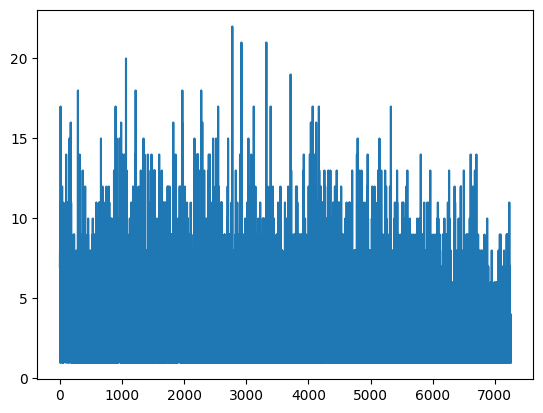

In [120]:
import matplotlib.pyplot as plt
plt.plot(turn_cts[12500:])
plt
sum(turn_cts[12500:])/len(turn_cts[12500:])
# values

tensor(8.8818e-16) tensor(9.0456e-07) tensor(7.5692e-06, grad_fn=<DivBackward0>)


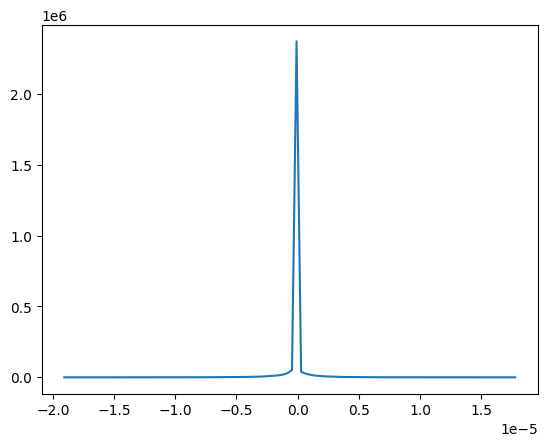

In [112]:
params = value_net[3].weight
p_grad = params.grad
mean = p_grad.mean()
std = p_grad.std()
rat = std / params.std()
print(mean, std, rat)
hy, hx = torch.histogram(p_grad, density=True)
plt.plot(hx.detach()[:-1], hy.detach())
plt.show()

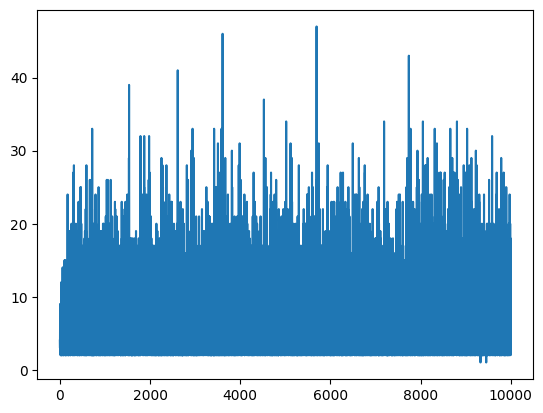

In [37]:
plt.plot(turn_cts)